In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
from collections import defaultdict, Counter
import networkx as nx

In [8]:
summary_df = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/contact_interface_data/rank1_contact_summary_5A.parquet")

print(summary_df.head())

                                     binder_sequence      method  \
0  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...         AF2   
1  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...         AF3   
2  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...     Boltz-2   
3  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      Chai-1   
4  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...  HelixFold3   

                                                path file_type  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .cif   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .cif   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .cif   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .cif   

  binder_chain_id target_chain_id     score       score_name  contact_cutoff  \
0               B               A  0.903964         iptm+ptm            10.0   
1               A               B 

In [9]:
target_long_df = pd.read_parquet(
    "/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/contact_interface_data/rank1_target_contacts_long_5A.parquet"
)

print(target_long_df.head())

                                     binder_sequence method  \
0  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   
1  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   
2  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   
3  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   
4  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...    AF2   

                                                path file_type  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb   

  binder_chain_id target_chain_id     score score_name  contact_cutoff  \
0               B               A  0.903964   iptm+ptm            10.0   
1               B               A  0.903964   iptm+ptm            10.0   
2 

In [10]:
rmsd_df = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/rmsd_data/pairwise_method_comparisons_rank1_with_binder_ca_rmsd_and_target_shell_rmsd.parquet")
print(rmsd_df.head())

                                     binder_sequence method_1    method_2  \
0  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2         AF3   
1  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2     Boltz-2   
2  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2      Chai-1   
3  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2  HelixFold3   
4  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      AF2         OF2   

                                    structure_path_1  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   

                                    structure_path_2 file_type_1 file_type_2  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...        .pdb        .cif   
1  /home/postyr/Assessing-AI-Scoring-Acc

In [11]:
seq = "SRFSNCPRRYRGICTNSGECTYAKNLRTYTCQCVSGYTGHRCEELDIRYL"
rmsd_col = "binder_ca_rmsd_align_target_shell"

af3_seq_df = rmsd_df[
    (rmsd_df["binder_sequence"] == seq) &
    ((rmsd_df["method_1"] == "AF3") | (rmsd_df["method_2"] == "AF3"))
].copy()

af3_seq_df["other_method"] = af3_seq_df.apply(
    lambda row: row["method_2"] if row["method_1"] == "AF3" else row["method_1"],
    axis=1
)

result = af3_seq_df[[
    "binder_sequence",
    "method_1",
    "method_2",
    "other_method",
    rmsd_col
]]

print(result)

                                         binder_sequence method_1    method_2  \
12423  SRFSNCPRRYRGICTNSGECTYAKNLRTYTCQCVSGYTGHRCEELD...      AF2         AF3   
12431  SRFSNCPRRYRGICTNSGECTYAKNLRTYTCQCVSGYTGHRCEELD...      AF3     Boltz-2   
12432  SRFSNCPRRYRGICTNSGECTYAKNLRTYTCQCVSGYTGHRCEELD...      AF3      Chai-1   
12433  SRFSNCPRRYRGICTNSGECTYAKNLRTYTCQCVSGYTGHRCEELD...      AF3  HelixFold3   
12434  SRFSNCPRRYRGICTNSGECTYAKNLRTYTCQCVSGYTGHRCEELD...      AF3         OF2   
12435  SRFSNCPRRYRGICTNSGECTYAKNLRTYTCQCVSGYTGHRCEELD...      AF3         OF3   
12436  SRFSNCPRRYRGICTNSGECTYAKNLRTYTCQCVSGYTGHRCEELD...      AF3    Protenix   
12437  SRFSNCPRRYRGICTNSGECTYAKNLRTYTCQCVSGYTGHRCEELD...      AF3    SeedFold   

      other_method  binder_ca_rmsd_align_target_shell  
12423          AF2                           0.872102  
12431      Boltz-2                           3.883022  
12432       Chai-1                           4.261712  
12433   HelixFold3                          15

In [12]:
test = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/prediction_records_new.parquet")
test.columns.to_list()

['path',
 'file_type',
 'method',
 'complex_name',
 'prediction_id',
 'rank',
 'target_chain_id',
 'binder_chain_id',
 'target_length',
 'binder_length',
 'binder_sequence',
 'target_sequence',
 'score',
 'score_name',
 'json_path',
 'pkl_path',
 'npz_path',
 'parse_success',
 'error_message']

In [13]:
df_csv = pd.read_csv("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/AdaptyvBio/contest_2_round_2_metrics_summary.csv")

In [14]:
rmsd_merged = rmsd_df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
rmsd_merged = rmsd_merged.drop(columns=["sequence"])

In [15]:
target_merged = target_long_df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
target_merged = target_merged.drop(columns=["sequence"])

In [16]:
plot_rmsd = rmsd_merged[rmsd_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()

In [17]:
plot_rmsd.head()

,binder_sequence,method_1,method_2,structure_path_1,structure_path_2,file_type_1,file_type_2,binder_chain_1,binder_chain_2,target_chain_1,...,error,binder_ca_rmsd_align_target_shell,n_shell_residues_ref,n_shell_ca_aligned,n_binder_ca_compared,target_shell_cutoff,status_target_shell,error_target_shell,design_class,binding
36,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,AF3,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,.pdb,.cif,B,A,A,...,None,0.687009,97,97,90,10.0,ok,None,Miniprotein,False
37,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,Boltz-2,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,.pdb,.cif,B,A,A,...,None,1.197764,97,97,90,10.0,ok,None,Miniprotein,False
38,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,Chai-1,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,.pdb,.cif,B,A,A,...,None,0.681339,97,97,90,10.0,ok,None,Miniprotein,False
39,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,HelixFold3,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,.pdb,.cif,B,A-1,A,...,None,0.779947,97,97,90,10.0,ok,None,Miniprotein,False
40,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,AF2,OF2,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,/home/postyr/Assessing-AI-Scoring-Accuracy-for...,.pdb,.pdb,B,A,A,...,None,0.312088,97,97,90,10.0,ok,None,Miniprotein,False


In [18]:
plot_target = target_merged[target_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()
print(plot_target.columns)

Index(['binder_sequence', 'method', 'path', 'file_type', 'binder_chain_id',
       'target_chain_id', 'score', 'score_name', 'contact_cutoff',
       'target_resseq', 'target_icode', 'design_class', 'binding'],
      dtype='str')


In [19]:
# Create contact sets: (binder, method) → set of residues
contact_sets = (
    plot_target
    .groupby(["binder_sequence", "method", "binding"])["target_resseq"]
    .apply(lambda x: set(x.dropna()))
    .reset_index(name="contact_set")
)

rows = []

for binder, group in contact_sets.groupby("binder_sequence"):
    methods = group["method"].values
    sets = group["contact_set"].values
    
    # all rows in group have same Binding → just take first
    binding = group["binding"].iloc[0]
    
    for (m1, s1), (m2, s2) in combinations(zip(methods, sets), 2):
        if len(s1 | s2) == 0:
            jaccard = 0.0
        else:
            jaccard = len(s1 & s2) / len(s1 | s2)
        
        rows.append({
            "binder_sequence": binder,
            "method_1": m1,
            "method_2": m2,
            "jaccard": jaccard,
            "Binding": binding   # ← add it here
        })

jaccard_df = pd.DataFrame(rows)

In [20]:
zero_jaccard_df = jaccard_df[jaccard_df["jaccard"] == 0].copy()

binder_pocket_dict = {}

for binder, group in zero_jaccard_df.groupby("binder_sequence"):
    # All methods involved
    methods = set(group["method_1"]).union(group["method_2"])
    
    # Graph: nodes = methods
    G = nx.Graph()
    G.add_nodes_from(methods)
    
    # Add edges ONLY when J = 0 (complete disagreement)
    for _, row in group.iterrows():
        if row["jaccard"] == 0:
            G.add_edge(row["method_1"], row["method_2"])
    
    # Connected components = disagreement groups
    clusters = list(nx.connected_components(G))
    
    binder_pocket_dict[binder] = clusters


In [21]:
zero_jaccard_df["method_pair"] = zero_jaccard_df.apply(
    lambda row: tuple(sorted([row["method_1"], row["method_2"]])),
    axis=1
)

binder_zero_dict = (
    zero_jaccard_df
    .groupby("binder_sequence")
    .apply(lambda df: list(zip(df["method_1"], df["method_2"])))
    .to_dict()
)

binder = list(binder_zero_dict.keys())[0]
print(binder)
print(binder_zero_dict[binder])

ATPYAGTMASAYDSATP
[('AF2', 'AF3'), ('AF2', 'Boltz-2'), ('AF2', 'Chai-1'), ('AF2', 'HelixFold3'), ('AF2', 'OF2'), ('AF2', 'OF3'), ('AF2', 'Protenix'), ('AF2', 'SeedFold')]


In [22]:
binder_zero_summary = pd.DataFrame({
    "binder_sequence": list(binder_zero_dict.keys()),
    "zero_pairs": [len(v) for v in binder_zero_dict.values()]
}).sort_values("zero_pairs", ascending=False)

In [23]:
jaccard_df.groupby("binder_sequence")["Binding"].nunique().value_counts()

Binding
1    197
Name: count, dtype: int64

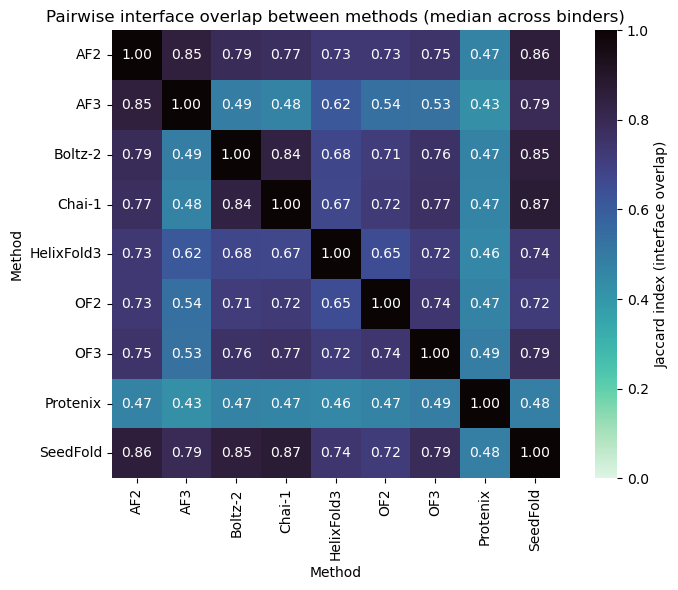

In [24]:
# Median Jaccard per method pair
jaccard_matrix = (
    jaccard_df
    .groupby(["method_1", "method_2"])["jaccard"]
    .median()
    .unstack()
)

# Make symmetric
jaccard_matrix = jaccard_matrix.combine_first(jaccard_matrix.T)

# Use one shared method order
method_order = sorted(set(jaccard_df["method_1"]).union(jaccard_df["method_2"]))

jaccard_matrix = jaccard_matrix.reindex(
    index=method_order,
    columns=method_order
)

# Fill diagonal
for m in method_order:
    jaccard_matrix.loc[m, m] = 1.0

plt.figure(figsize=(8, 6))
sns.heatmap(
    jaccard_matrix,
    annot=True,
    fmt=".2f",
    cmap="mako_r",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label": "Jaccard index (interface overlap)"}
)

plt.title("Pairwise interface overlap between methods (median across binders)")
plt.xlabel("Method")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

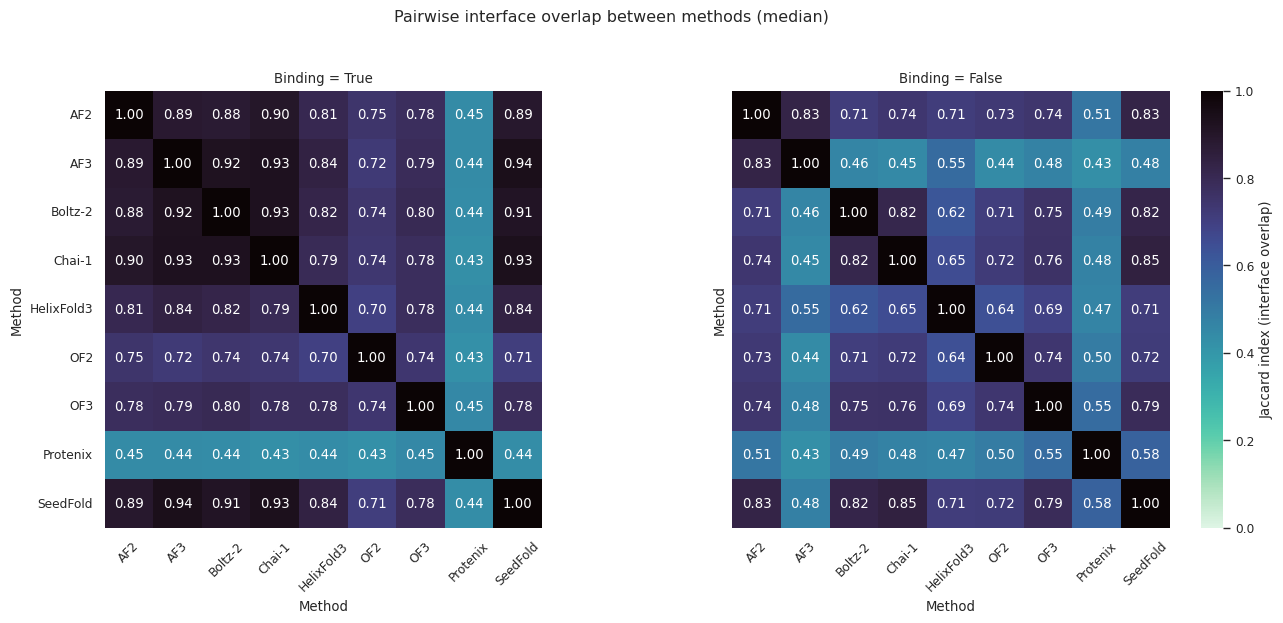

In [25]:
method_order = sorted(set(jaccard_df["method_1"]).union(jaccard_df["method_2"]))

def make_jaccard_matrix(df):
    matrix = (
        df
        .groupby(["method_1", "method_2"])["jaccard"]
        .median()
        .unstack()
    )

    matrix = matrix.combine_first(matrix.T)
    matrix = matrix.reindex(index=method_order, columns=method_order)

    for m in method_order:
        matrix.loc[m, m] = 1.0

    return matrix


binding_matrix = make_jaccard_matrix(jaccard_df[jaccard_df["Binding"] == True])
nonbinding_matrix = make_jaccard_matrix(jaccard_df[jaccard_df["Binding"] == False])

sns.set_theme(style="white", context="paper")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

sns.heatmap(
    binding_matrix,
    ax=axes[0],
    annot=True,
    fmt=".2f",
    cmap="mako_r",   # ← reversed colormap
    vmin=0,
    vmax=1,
    square=True,
    cbar=False
)

sns.heatmap(
    nonbinding_matrix,
    ax=axes[1],
    annot=True,
    fmt=".2f",
    cmap="mako_r",   # ← reversed here too
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label": "Jaccard index (interface overlap)"}
)

axes[0].set_title("Binding = True")
axes[1].set_title("Binding = False")

for ax in axes:
    ax.set_xlabel("Method")
    ax.set_ylabel("Method")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Pairwise interface overlap between methods (median)", y=1.03)

plt.tight_layout()
plt.show()

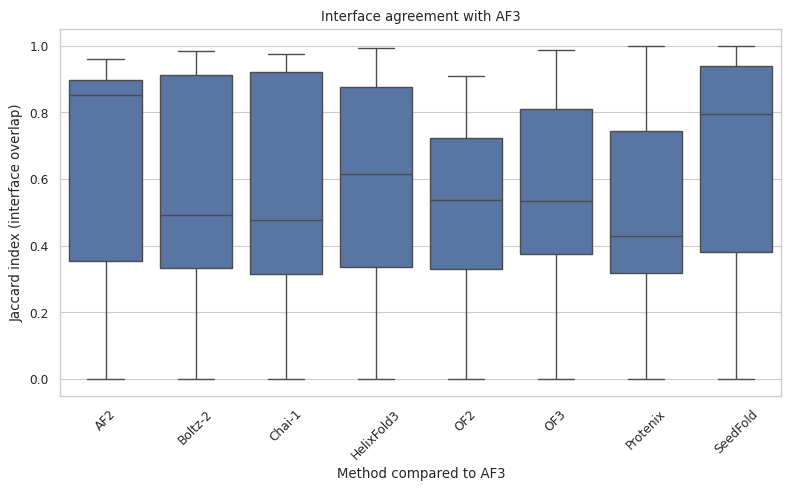

In [26]:
ref = "AF3"

ref_df = jaccard_df[
    (jaccard_df["method_1"] == ref) |
    (jaccard_df["method_2"] == ref)
].copy()

ref_df["other_method"] = ref_df.apply(
    lambda row: row["method_2"] if row["method_1"] == ref else row["method_1"],
    axis=1
)

sns.set_theme(
    style="whitegrid",
    context="paper",   # IMPORTANT: scales fonts for publication
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=ref_df,
    x="other_method",
    y="jaccard"
)

plt.ylabel("Jaccard index (interface overlap)")
plt.xlabel("Method compared to AF3")
plt.title("Interface agreement with AF3")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

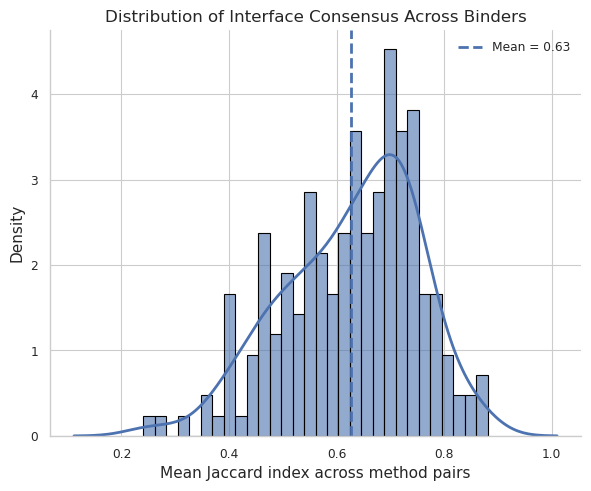

In [27]:
binder_consensus = (
    jaccard_df
    .groupby("binder_sequence")["jaccard"]
    .mean()
    .reset_index(name="mean_jaccard")
)
mean_val = binder_consensus["mean_jaccard"].mean()

sns.set(style="whitegrid", context="paper")

plt.figure(figsize=(6, 5))

# Histogram
sns.histplot(
    data=binder_consensus,
    x="mean_jaccard",
    bins=30,
    stat="density",        # important for overlaying KDE
    alpha=0.6,
    edgecolor="black"
)

# KDE line (smooth distribution)
sns.kdeplot(
    data=binder_consensus,
    x="mean_jaccard",
    linewidth=2
)

# Mean line
plt.axvline(
    mean_val,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_val:.2f}"
)

# Labels
plt.xlabel("Mean Jaccard index across method pairs", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.title("Distribution of Interface Consensus Across Binders", fontsize=12)

# Legend
plt.legend(frameon=False)

# Clean look
sns.despine()

plt.tight_layout()
plt.show()

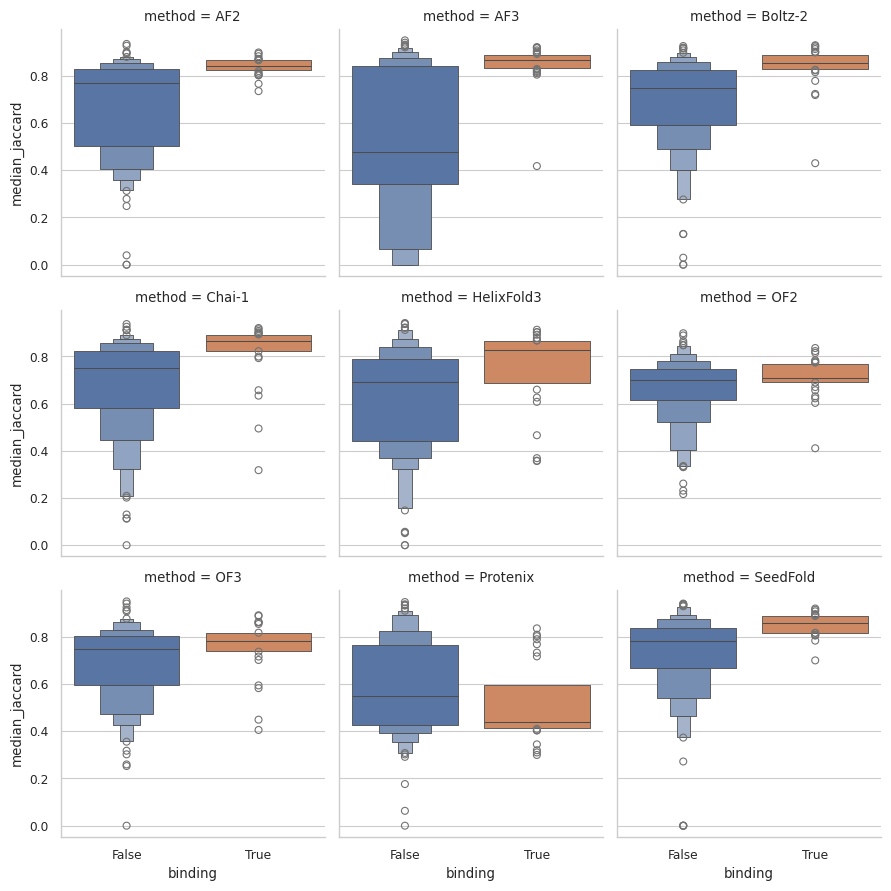

In [28]:
binder_binding = df_csv[["sequence", "binding"]].copy().drop_duplicates().rename(columns={"sequence": "binder_sequence"})

jaccard_long = pd.concat([
    jaccard_df.rename(columns={"method_1": "method", "method_2": "other"}),
    jaccard_df.rename(columns={"method_2": "method", "method_1": "other"})
])

model_jaccard = (
    jaccard_long
    .groupby(["binder_sequence", "method"])["jaccard"]
    .median()
    .reset_index()
    .rename(columns={"jaccard": "median_jaccard"}))

# Add binding label
model_jaccard = model_jaccard.merge(
    binder_binding,
    on="binder_sequence"
)
palette = {
    False: "#4C72B0",   # blue
    True: "#DD8452"   # orange
}

sns.set_theme(
    style="whitegrid",
    context="paper",   # IMPORTANT: scales fonts for publication
)

sns.catplot(
    data=model_jaccard,
    x="binding",
    y="median_jaccard",
    col="method",
    kind="boxen",
    col_wrap=3,
    height=3,
    sharey=True,
    hue="binding",        # ← important
    palette=palette,      # ← your colors
    legend=False          # ← avoid duplicate legend per facet
)

plt.show()

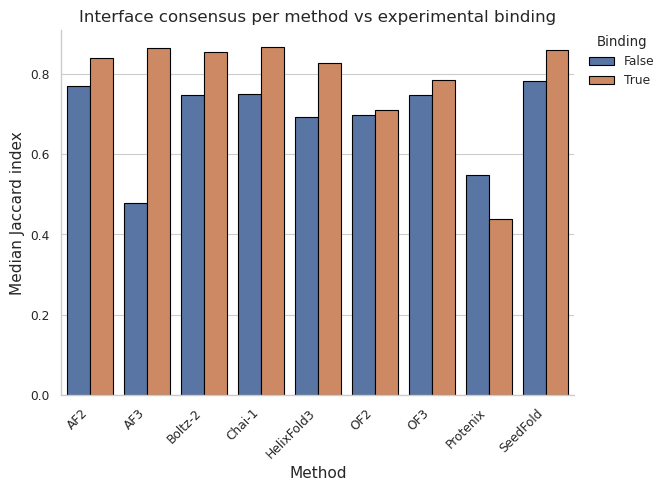

In [29]:
summary = (
    model_jaccard
    .groupby(["method", "binding"])["median_jaccard"]
    .median()
    .reset_index()
)

palette = {
    False: "#4C72B0",   # blue
    True: "#DD8452"   # orange
}

sns.set_theme(style="whitegrid", context="paper")

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=summary,
    x="method",
    y="median_jaccard",
    hue="binding",
    palette=palette,
    edgecolor="black"
)

# Improve labels
ax.set_xlabel("Method", fontsize=11)
ax.set_ylabel("Median Jaccard index", fontsize=11)
ax.set_title("Interface consensus per method vs experimental binding", fontsize=12)

# Rotate x labels for readability
plt.xticks(rotation=45, ha="right")

# Clean legend
plt.legend(
    title="Binding",
    frameon=False,
    bbox_to_anchor=(1.02, 1),  # move outside right
    loc="upper left",
    borderaxespad=0
)

# Remove top/right spines
sns.despine()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [30]:
from scipy.stats import mannwhitneyu

results = []

for method, df in model_jaccard.groupby("method"):
    bind = df[df["binding"] == True]["median_jaccard"]
    nobind = df[df["binding"] == False]["median_jaccard"]
    
    stat, p = mannwhitneyu(bind, nobind)
    
    results.append({
        "method": method,
        "p_value": p,
        "effect": bind.median() - nobind.median()
    })

pd.DataFrame(results).sort_values("effect", ascending=False)

,method,p_value,effect
1,AF3,1.494016e-07,0.386826
4,HelixFold3,1.152568e-03,0.133584
3,Chai-1,9.062458e-07,0.115136
2,Boltz-2,2.013995e-07,0.108177
8,SeedFold,2.942380e-06,0.077840
0,AF2,4.193363e-07,0.069792
6,OF3,3.783184e-02,0.035909
5,OF2,8.401785e-02,0.011117
7,Protenix,4.994988e-02,-0.109915


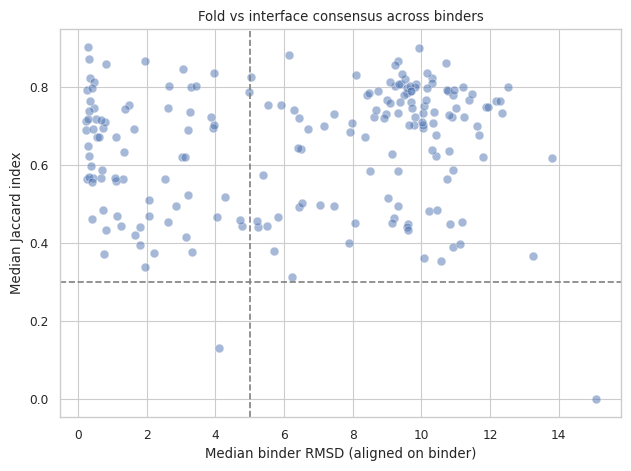

In [31]:
# Jaccard summary per binder
binder_jaccard_summary = (
    jaccard_df
    .groupby("binder_sequence", as_index=False)["jaccard"]
    .median()
    .rename(columns={"jaccard": "median_jaccard"})
)

# RMSD summary per binder (aligned on binder)
binder_rmsd_summary = (
    plot_rmsd
    .groupby("binder_sequence", as_index=False)["binder_ca_rmsd_align_binder"]
    .median()
    .rename(columns={"binder_ca_rmsd_align_binder": "median_binder_rmsd"})
)

# Merge
consensus_df = binder_jaccard_summary.merge(
    binder_rmsd_summary,
    on="binder_sequence",
    how="inner"
)

sns.set_theme(
    style="whitegrid",
    context="paper",   # IMPORTANT: scales fonts for publication
)

sns.scatterplot(
    data=consensus_df,
    x="median_binder_rmsd",
    y="median_jaccard",
    alpha=0.5,
    s=40
)
plt.axvline(x=5, linestyle="--", color="grey")   # example RMSD cutoff
plt.axhline(y=0.3, linestyle="--", color="grey") # example Jaccard cutoff
plt.xlabel("Median binder RMSD (aligned on binder)")
plt.ylabel("Median Jaccard index")
plt.title("Fold vs interface consensus across binders")
plt.tight_layout()
plt.show()

In [32]:
binder_rmsd_target = (
    plot_rmsd
    .groupby("binder_sequence", as_index=False)["binder_ca_rmsd_align_target_shell"]
    .median()
    .rename(columns={"binder_ca_rmsd_align_target_shell": "median_binder_rmsd_target"})
)

consensus_df_shell = binder_jaccard_summary.merge(
    binder_rmsd_target,
    on="binder_sequence",
    how="inner"
)

binder_df_target = (
    binder_jaccard_summary
    .merge(binder_rmsd_target, on="binder_sequence")
    .merge(binder_binding, on="binder_sequence")
)

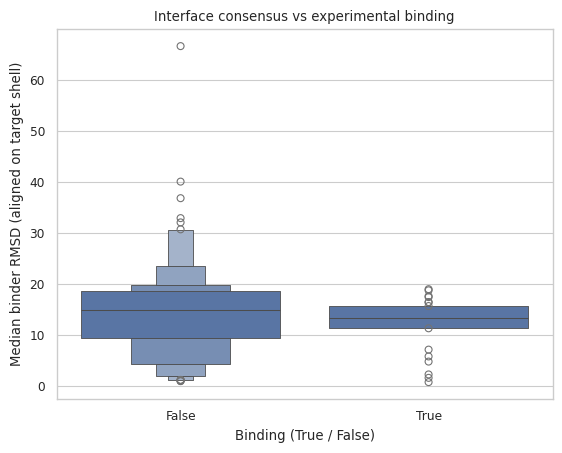

In [33]:
sns.boxenplot(
    data=binder_df_target,
    x="binding",
    y="median_binder_rmsd_target"
)

plt.title("Interface consensus vs experimental binding")
plt.ylabel("Median binder RMSD (aligned on target shell)")
plt.xlabel("Binding (True / False)")
plt.show()

In [34]:
# Binding label (important: take one per binder)
# binder_binding = (
#     plot_rmsd[["binder_sequence", "binding"]]
#     .drop_duplicates()
# )

# Merge everything
binder_df = (
    binder_jaccard_summary
    .merge(binder_rmsd_summary, on="binder_sequence")
    .merge(binder_binding, on="binder_sequence")
)

binder_df.head()

,binder_sequence,median_jaccard,median_binder_rmsd,binding
0,AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...,0.717277,0.522551,False
1,AECPEEYKNYCKHGTCLYDVKKNKPVCLCDKGYLGPRCEKKDLSLLL,0.496154,2.854206,False
2,AESHFSECPASLQNFCQNGTCRFHVGLNQPACICNRGYIGSRCELR...,0.807692,9.848934,False
3,ANSYSPCPLEYKGYCKNGGVCVYIEATNTYACICVPGYYGPRCEYKDPK,0.642607,6.501615,False
4,APLTEYEKKIEELWDVVHNVPDMEVRRKAIDLVFDLQVTHKITEEQ...,0.671875,0.570838,True


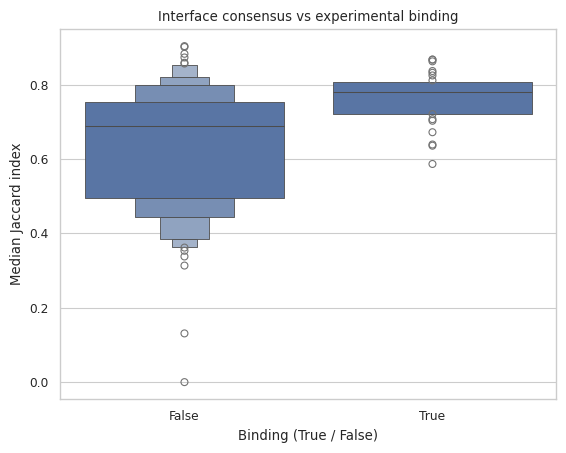

In [35]:
sns.boxenplot(
    data=binder_df,
    x="binding",
    y="median_jaccard"
)

plt.title("Interface consensus vs experimental binding")
plt.ylabel("Median Jaccard index")
plt.xlabel("Binding (True / False)")
plt.show()

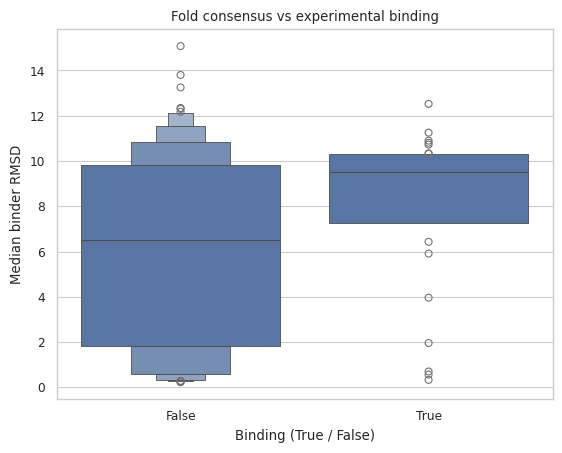

In [36]:
sns.boxenplot(
    data=binder_df,
    x="binding",
    y="median_binder_rmsd"
)

plt.title("Fold consensus vs experimental binding")
plt.ylabel("Median binder RMSD")
plt.xlabel("Binding (True / False)")
plt.show()

In [37]:
from scipy.stats import mannwhitneyu

u, p = mannwhitneyu(
    binder_df[binder_df["binding"] == True]["median_jaccard"],
    binder_df[binder_df["binding"] == False]["median_jaccard"]
)

print(p)

3.4635669573939245e-05


for a single binder-method structure, the distribution is effectively:

uniform over the contacted target residues and zero over all non-contacted residues

So for one binder:

if AF2 contacts 20 target residues, each gets roughly probability 1/20

if AF3 contacts 10 target residues, each gets roughly probability 1/10

it means KL is measuring:
how different the contacted target-residue sets are, plus how broad/narrow each interface is

In [38]:
method_residue_matrix = (
    plot_target
    .groupby(["method", "target_resseq"])
    .size()
    .unstack(fill_value=0)
)

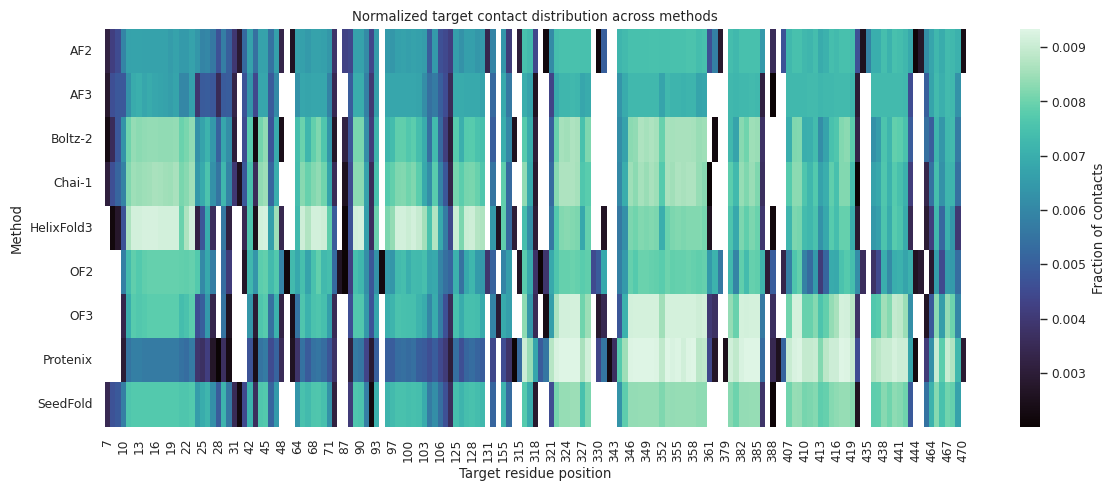

In [39]:
# Normalize within each method
contact_fraction_matrix = (
    method_residue_matrix
    .div(method_residue_matrix.sum(axis=1), axis=0)
    .fillna(0)
)

# Set your visibility threshold
threshold = 0.002

# Keep only values above threshold
plot_matrix = contact_fraction_matrix.where(contact_fraction_matrix >= threshold)

# Drop residue columns where no method has a visible hit
plot_matrix = plot_matrix.loc[:, plot_matrix.notna().any(axis=0)]

sns.set_theme(style="white", context="paper")

plt.figure(figsize=(12, 5))
ax = sns.heatmap(
    plot_matrix,
    cmap="mako",
    mask=plot_matrix.isna(),
    cbar_kws={"label": "Fraction of contacts"}
)

ax.set_xlabel("Target residue position")
ax.set_ylabel("Method")
ax.set_title("Normalized target contact distribution across methods")

plt.tight_layout()
plt.show()

In [40]:
rmsd_mean = (
    plot_rmsd
    .groupby(["method_1", "method_2"], as_index=False)["binder_ca_rmsd_align_target_shell"]
    .mean()
)

rmsd_col = "binder_ca_rmsd_align_target_shell"

rmsd_median = (
    plot_rmsd
    .groupby(["method_1", "method_2"], as_index=False)[rmsd_col]
    .median()
    .rename(columns={rmsd_col: "pair_median_rmsd"})
)

rmsd_median.head()

,method_1,method_2,pair_median_rmsd
0,AF2,AF3,2.087449
1,AF2,Boltz-2,3.740203
2,AF2,Chai-1,3.035571
3,AF2,HelixFold3,13.412490
4,AF2,OF2,14.485943


In [41]:
plot_rmsd_with_median = plot_rmsd.merge(rmsd_median, on=["method_1", "method_2"], how="left")

plot_rmsd_with_median.columns.to_list()

['binder_sequence',
 'method_1',
 'method_2',
 'structure_path_1',
 'structure_path_2',
 'file_type_1',
 'file_type_2',
 'binder_chain_1',
 'binder_chain_2',
 'target_chain_1',
 'target_chain_2',
 'score_1',
 'score_2',
 'score_name_1',
 'score_name_2',
 'binder_ca_rmsd_align_binder',
 'n_ca_aligned',
 'binder_len_1',
 'binder_len_2',
 'status',
 'error',
 'binder_ca_rmsd_align_target_shell',
 'n_shell_residues_ref',
 'n_shell_ca_aligned',
 'n_binder_ca_compared',
 'target_shell_cutoff',
 'status_target_shell',
 'error_target_shell',
 'design_class',
 'binding',
 'pair_median_rmsd']

In [42]:
plot_rmsd_with_median["dist_to_pair_median"] = (
    plot_rmsd_with_median[rmsd_col] - plot_rmsd_with_median["pair_median_rmsd"]
).abs()

representative_examples = (
    plot_rmsd_with_median
    .sort_values(["method_1", "method_2", "dist_to_pair_median"])
    .groupby(["method_1", "method_2"], as_index=False)
    .head(3)
    .copy()
)

In [43]:
plot_rmsd_with_median[
    ["method_1", "method_2", "binder_ca_rmsd_align_target_shell", "pair_median_rmsd", "dist_to_pair_median"]
].head(20)

,method_1,method_2,binder_ca_rmsd_align_target_shell,pair_median_rmsd,dist_to_pair_median
0,AF2,AF3,0.687009,2.087449,1.400440
1,AF2,Boltz-2,1.197764,3.740203,2.542439
2,AF2,Chai-1,0.681339,3.035571,2.354232
3,AF2,HelixFold3,0.779947,13.412490,12.632543
4,AF2,OF2,0.312088,14.485943,14.173855
5,AF2,OF3,0.585104,13.599036,13.013932
6,AF2,Protenix,0.992278,16.778810,15.786532
7,AF2,SeedFold,0.780936,2.125004,1.344068
8,AF3,Boltz-2,1.045234,4.285082,3.239849
9,AF3,Chai-1,0.911739,4.261712,3.349973


In [44]:
cols = [
    "binder_sequence",   # or binder_id if you have one
    "method_1",
    "method_2",
    "structure_path_1",
    "structure_path_2",
    "binder_ca_rmsd_align_target_shell",   # or your rmsd_col
    "pair_median_rmsd",
    "dist_to_pair_median",
]

rep_view = representative_examples[cols].copy()
print(rep_view.head(30))

                                        binder_sequence method_1    method_2  \
3528  PNLESCPSSHDSYCLYQGVCFYFPEMESYACKSVQGYVGERCQFSD...      AF2         AF3   
2016  LLFFSQCPLSHDGYCLHDGVCMYIEALDKYACNCVVGYIGERCQYR...      AF2         AF3   
3240  PDTIASCPSSHESYCLYQGVCFYFPEMESYACNCVSGYMGERCQFS...      AF2         AF3   
1189                               EQEKADVINEYREKKAFAFF      AF2     Boltz-2   
5545  SRFSNCPRRYRGICTNSGECTYAKNLRTYTCQCVSGYTGHRCEELD...      AF2     Boltz-2   
6949                   YCLHGTPVYISSLNKWSCVCDKGWYGERCEFR      AF2     Boltz-2   
1118  ELPDVLFIEASAEDCEKAFEEAFEKFIKGEVGIFTLKCDGSPELEH...      AF2      Chai-1   
1802   KIKFLEEIEIDGKKFKILYIEDINEIAVKASDTSATPEQIQKAIEKAK      AF2      Chai-1   
2990  NNLYKRCAQSHDGYCLHDGVCMYIEALDKYACNCVVGYIGERCQYR...      AF2      Chai-1   
6843      TYDGYCLNGGKCEHVESLDKYTCNCVSGYTGDRCQERDLRWLEHQ      AF2  HelixFold3   
4611  SHFNKCPENHRGFCFHGTCRFLYLENKPACICHPGYVGARCEEADL...      AF2  HelixFold3   
6411    TCPEYYKGYCLHNAECYYIEALNDVGCQCKKG

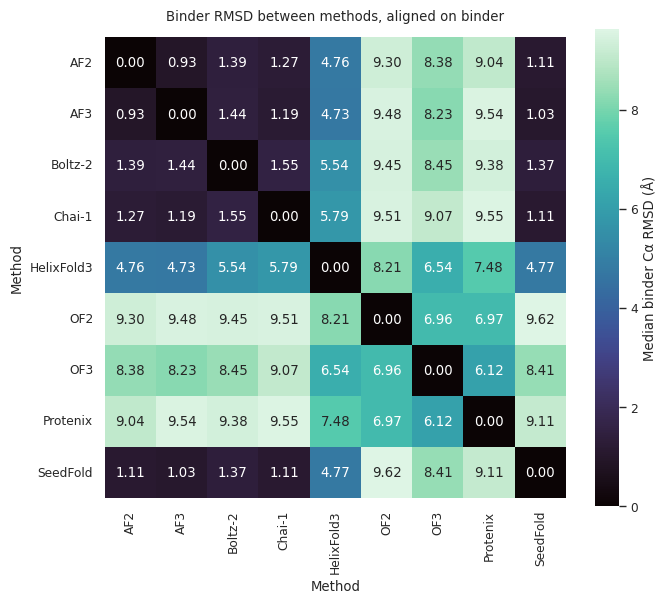

In [45]:
rmsd_col = "binder_ca_rmsd_align_binder"

rmsd_matrix = (
    plot_rmsd
    .groupby(["method_1", "method_2"])[rmsd_col]
    .median()
    .unstack()
)

rmsd_matrix = rmsd_matrix.combine_first(rmsd_matrix.T)

method_order = sorted(set(plot_rmsd["method_1"]) | set(plot_rmsd["method_2"]))
rmsd_matrix = rmsd_matrix.reindex(index=method_order, columns=method_order)

for m in rmsd_matrix.index:
    rmsd_matrix.loc[m, m] = 0.0

sns.set_theme(style="white", context="paper")

plt.figure(figsize=(7, 6))
ax = sns.heatmap(
    rmsd_matrix,
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Median binder Cα RMSD (Å)"}
)

ax.set_title("Binder RMSD between methods, aligned on binder", pad=12)
ax.set_xlabel("Method")
ax.set_ylabel("Method")

plt.tight_layout()
plt.show()

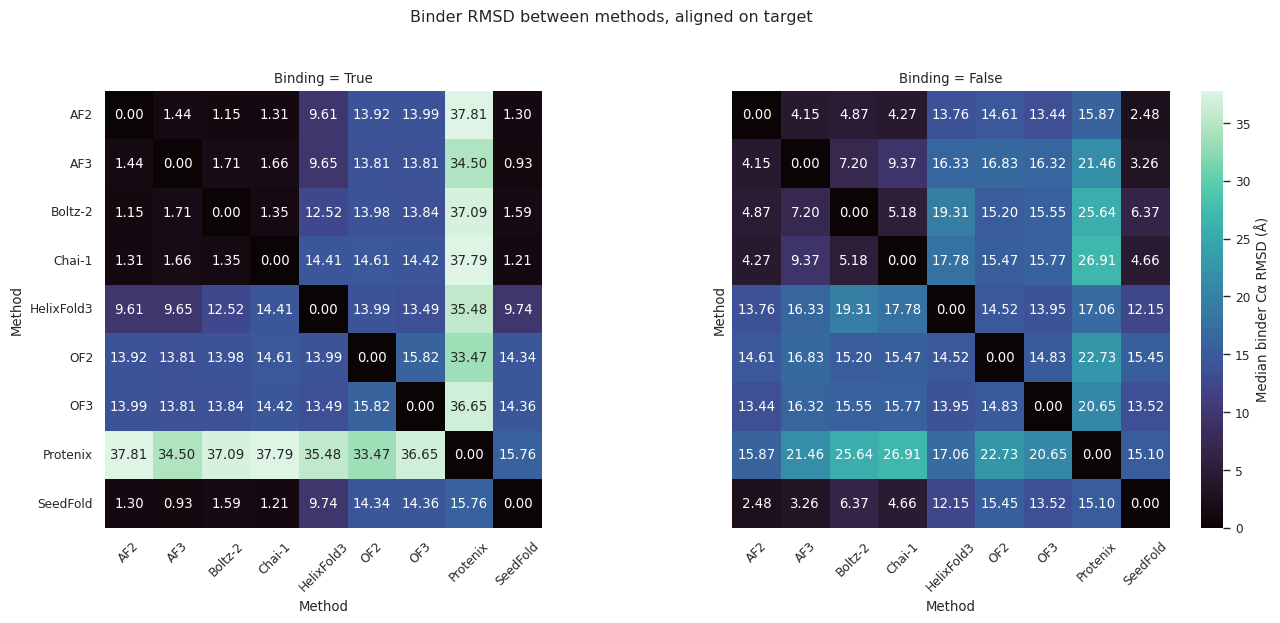

In [46]:
rmsd_col = "binder_ca_rmsd_align_target_shell"

method_order = sorted(set(plot_rmsd["method_1"]) | set(plot_rmsd["method_2"]))

def make_rmsd_matrix(df):
    matrix = (
        df
        .groupby(["method_1", "method_2"])[rmsd_col]
        .median()
        .unstack()
    )

    matrix = matrix.combine_first(matrix.T)
    matrix = matrix.reindex(index=method_order, columns=method_order)

    for m in matrix.index:
        matrix.loc[m, m] = 0.0

    return matrix


binding_matrix = make_rmsd_matrix(plot_rmsd[plot_rmsd["binding"] == True])
nonbinding_matrix = make_rmsd_matrix(plot_rmsd[plot_rmsd["binding"] == False])

sns.set_theme(style="white", context="paper")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

vmin = min(binding_matrix.min().min(), nonbinding_matrix.min().min())
vmax = max(binding_matrix.max().max(), nonbinding_matrix.max().max())

sns.heatmap(
    binding_matrix,
    ax=axes[0],
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    vmin=vmin,
    vmax=vmax,
    cbar=False
)

sns.heatmap(
    nonbinding_matrix,
    ax=axes[1],
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    vmin=vmin,
    vmax=vmax,
    cbar_kws={"label": "Median binder Cα RMSD (Å)"}
)

axes[0].set_title("Binding = True")
axes[1].set_title("Binding = False")

for ax in axes:
    ax.set_xlabel("Method")
    ax.set_ylabel("Method")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Binder RMSD between methods, aligned on target", y=1.03)

plt.tight_layout()
plt.show()

In [47]:
ref = "AF3"
rmsd_col = "binder_ca_rmsd_align_target_shell"  # adjust if needed

af3_as_1 = plot_rmsd[plot_rmsd["method_1"] == ref].copy()
af3_as_1["other_method"] = af3_as_1["method_2"]

af3_as_2 = plot_rmsd[plot_rmsd["method_2"] == ref].copy()
af3_as_2["other_method"] = af3_as_2["method_1"]

af3_all = pd.concat([af3_as_1, af3_as_2], ignore_index=True)

print(sorted(af3_all["other_method"].unique()))

['AF2', 'Boltz-2', 'Chai-1', 'HelixFold3', 'OF2', 'OF3', 'Protenix', 'SeedFold']


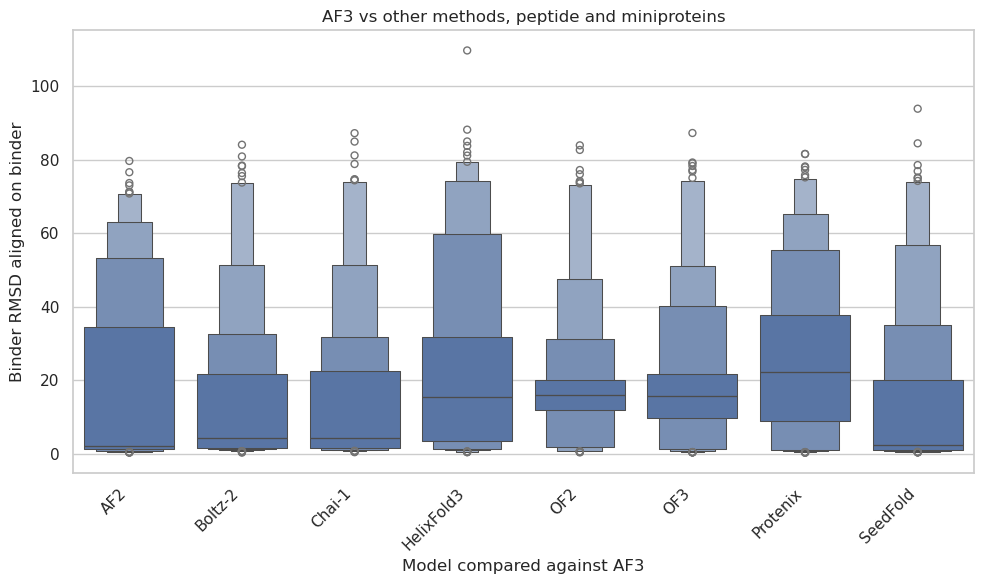

In [48]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.boxenplot(
    data=af3_all,
    x="other_method",
    y=rmsd_col,
    order=sorted(af3_all["other_method"].unique()),
    width_method="linear"
)

plt.xlabel("Model compared against AF3")
plt.ylabel("Binder RMSD aligned on binder")
plt.title("AF3 vs other methods, peptide and miniproteins")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [55]:
(af3_all["binder_ca_rmsd_align_binder"] < 0).any()


np.False_

In [61]:
print(af3_all.head())

                                     binder_sequence method_1    method_2  \
0  AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...      AF3     Boltz-2   
1  AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...      AF3      Chai-1   
2  AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...      AF3  HelixFold3   
3  AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...      AF3         OF2   
4  AAVEEAKAAYAKAKAEYNAIVEPKRKAAEDLTEQANKEKPADKAAA...      AF3         OF3   

                                    structure_path_1  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...   

                                    structure_path_2 file_type_1 file_type_2  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...        .cif        .cif   
1  /home/postyr/Assessing-AI-Scoring-Acc

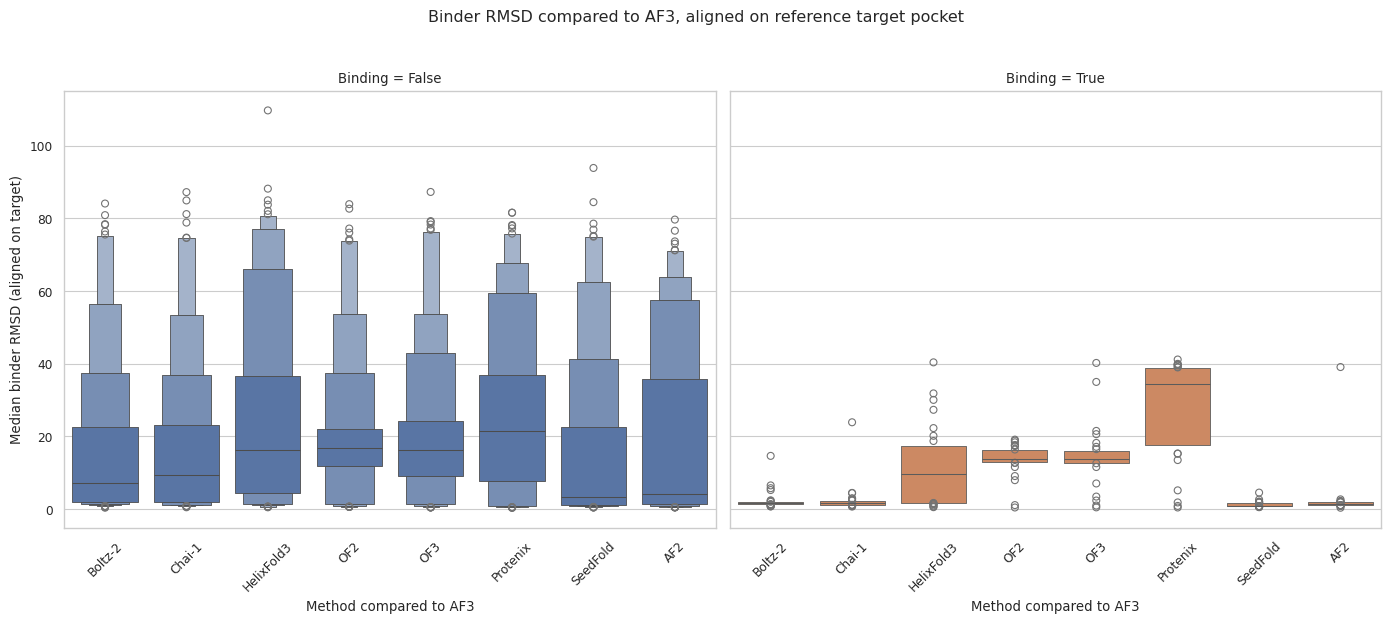

In [74]:
sns.set_theme(style="whitegrid", context="paper")

af3_nonbinding = af3_all[af3_all["binding"] == False]
af3_binding = af3_all[af3_all["binding"] == True]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)


sns.boxenplot(
    ax=axes[0],
    data=af3_nonbinding,          # your filtered DF (Peptide + Miniprotein)
    x="other_method",
    y=rmsd_col,
    color="#4C72B0",
    width_method="linear"
)


sns.boxenplot(
    ax=axes[1],
    data=af3_binding,          # your filtered DF (Peptide + Miniprotein)
    x="other_method",
    y=rmsd_col,
    color="#DD8452",
    width_method="linear"
)

axes[0].set_title("Binding = False")
axes[1].set_title("Binding = True")

for ax in axes:
    ax.set_ylabel("Median binder RMSD (aligned on target)")
    ax.set_xlabel("Method compared to AF3")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Binder RMSD compared to AF3, aligned on reference target pocket", y=1.03)

plt.tight_layout()
plt.show()


In [50]:
import pandas as pd

rmsd_col = "binder_ca_rmsd_align_target_shell"

# Stack both columns into one unified "method" column
part1 = plot_rmsd[["method_1", rmsd_col]].rename(columns={"method_1": "method"})
part2 = plot_rmsd[["method_2", rmsd_col]].rename(columns={"method_2": "method"})

long_df = pd.concat([part1, part2], ignore_index=True)

summary = (
    long_df
    .groupby("method")[rmsd_col]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean")
)

print(summary)

                 mean     median        std  count
method                                            
SeedFold    13.038062  10.038414  15.149856   1576
AF2         13.529594   9.355574  15.423354   1576
Boltz-2     15.687233  13.618392  15.269919   1576
Chai-1      15.718355  13.677597  15.272020   1576
OF2         16.820610  15.245467  11.797115   1576
OF3         17.182753  14.683387  13.548284   1576
HelixFold3  18.267003  14.691855  16.775369   1576
AF3         18.721070  13.897011  20.803154   1576
Protenix    23.473437  19.938049  16.900073   1576


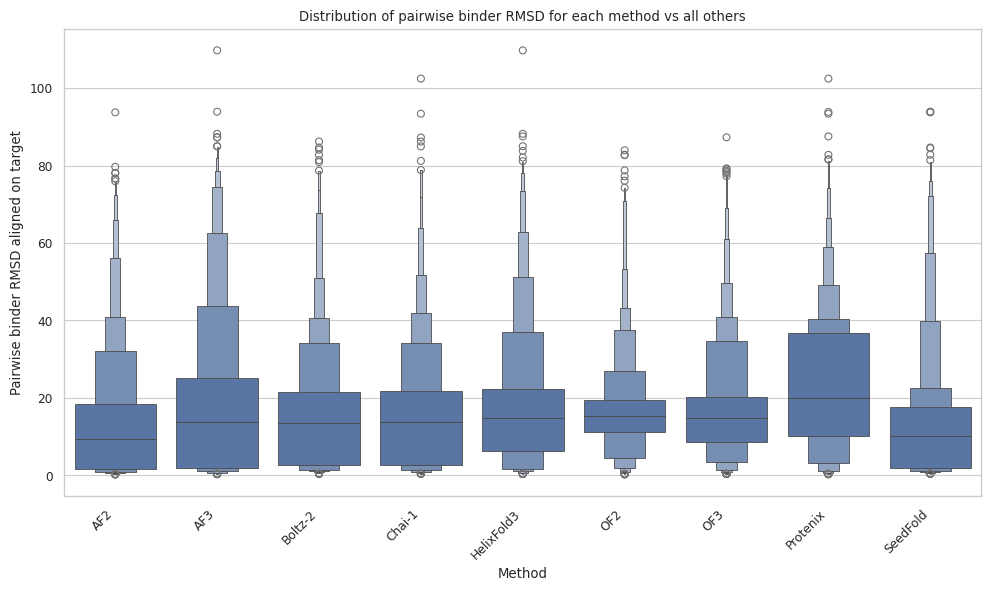

In [51]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.boxenplot(
    data=long_df,
    x="method",
    y=rmsd_col
)

plt.xlabel("Method")
plt.ylabel("Pairwise binder RMSD aligned on target")
plt.title("Distribution of pairwise binder RMSD for each method vs all others")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

which methods tend to produce poses most similar to the overall consensus across binders?

The lower the Pairwise RMSD, the more in agreement the model is in general with the other models.